First 5 rows:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Features shape: (150, 5)
Target shape: (150,)

Training set size: 120
Test set size: 30

Accuracy with max_iter=2: 0.3333

Classification Report (max_iter=2):
                 precision    recall  f1-score   support

    Iris-setosa       0.00      0.00      0.00        10
Iris-versicolor       0.00      0.00      0.00        10
 Iris-virginica       0.33      1.00      0.50        10

       accuracy                           0.33        30
      macro avg       0.11      0.33      0.17        30
   weighted avg    

/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is il

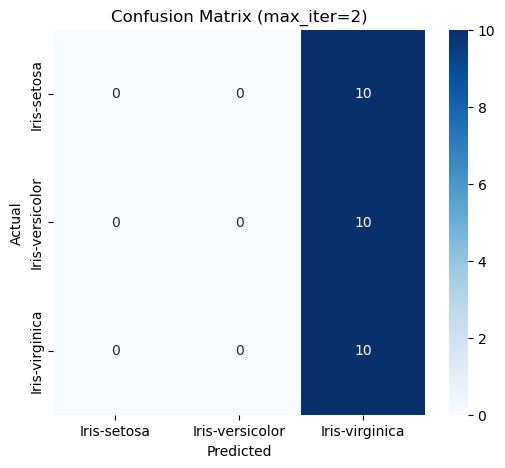


Experiment: different max_iter values
max_iter =   2 -> Accuracy = 0.3333
max_iter =   5 -> Accuracy = 0.7333
max_iter =  10 -> Accuracy = 0.8333
max_iter =  50 -> Accuracy = 1.0000
max_iter = 100 -> Accuracy = 1.0000


/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bernard/miniconda3/envs/ml_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depreca

max_iter = 200 -> Accuracy = 1.0000


In [3]:
# =====================================================
# Logistic Regression on Iris Dataset
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------
# 1. Load the Iris dataset
# ------------------------------------------------
df = pd.read_csv('Iris.csv')   # Make sure the file is in the same folder
print("First 5 rows:\n", df.head())

# ------------------------------------------------
# 2. Features (X) and target (y)
# ------------------------------------------------
X = df.drop('Species', axis=1)   # all columns except 'species'
y = df['Species']                 # target: species names

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# ------------------------------------------------
# 3. Split into training and test sets
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# ------------------------------------------------
# 4. Train logistic regression model
# ------------------------------------------------
# Start with max_iter = 2 (to see effect)
model = LogisticRegression(max_iter=2, multi_class='ovr', solver='lbfgs')
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# ------------------------------------------------
# 5. Evaluation
# ------------------------------------------------
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy with max_iter=2: {acc:.4f}")

# Classification report
print("\nClassification Report (max_iter=2):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix (max_iter=2)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ------------------------------------------------
# 6. Experiment with different max_iter values
# ------------------------------------------------
max_iter_values = [2, 5, 10, 50, 100, 200]
print("\n" + "="*60)
print("Experiment: different max_iter values")
print("="*60)

for max_iter in max_iter_values:
    model = LogisticRegression(max_iter=max_iter, multi_class='ovr', solver='lbfgs')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # Also check if the model converged
    print(f"max_iter = {max_iter:3d} -> Accuracy = {acc:.4f}")